In [2]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
from datetime import date

# Load data and get time

### background

#### 17/12

In [3]:
bg = {}

coinc1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Coincidence_histo.txt", skiprows=1)
timestamps1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Timestamp_ch0.txt", skiprows=1)

ctime1 = coinc1[:, 0]
counts1 = coinc1[:, 1]
t1 = timestamps1[:, 0]
time1 = (t1[-1] - t1[0]) * 1e-12

bg["d"] = {
    "ctime": ctime1,
    "counts": counts1,
    "time": time1
}

#### 18/03

In [4]:
coinc2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Coincidence_histo.txt", skiprows=1)
timestamps2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Timestamp_ch0.txt", skiprows=1)

ctime2 = coinc2[:, 0]
counts2 = coinc2[:, 1]
t2 = timestamps2[:, 0]
time2 = (t2[-1] - t2[0]) * 1e-12

bg["m"] = {
    "ctime": ctime2,
    "counts": counts2,
    "time": time2
}

### Na22

#### 17/12

In [5]:
na22d = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 Na22 pos{}"

for i in range(1, 10):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22d[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

#### 18/03

In [6]:
na22m = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_Na22Pos{}"

for i in range(1, 21):
    path = base_path.format(i)
    
    coinc = np.loadtxt(f"{path}\\Coincidence_histo.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    ctime = coinc[:, 0]
    counts = coinc[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22m[f"{i}"] = {
        "ctime": ctime,
        "counts": counts,
        "time": time
    }

---

# Subtract background

### background

#### 17/12

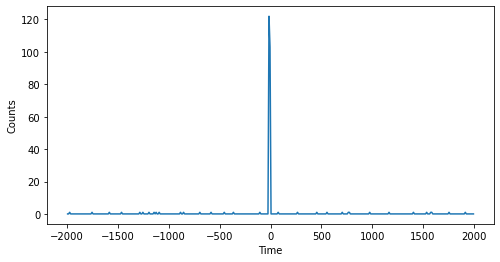

In [7]:
#spectrum background
range_bg = (bg["d"]["ctime"] > -2000) & (bg["d"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["d"]["ctime"][range_bg], bg["d"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

#### 18/03

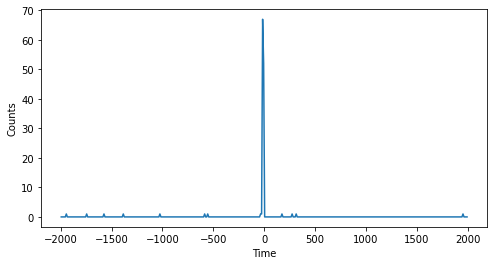

In [8]:
#spectrum background
range_bg = (bg["m"]["ctime"] > -2000) & (bg["m"]["ctime"] < 2000)
plt.figure(figsize=(8, 4))
plt.plot(bg["m"]["ctime"][range_bg], bg["m"]["counts"][range_bg])
plt.xlabel("Time")
plt.ylabel("Counts")
plt.show()

### Na22

#### 17/12

In [9]:
for key in na22d:
    counts_bg_na22 = bg["d"]["counts"] * (na22d[key]["time"] / bg["d"]["time"])
    na22d[key]["netcounts"] = na22d[key]["counts"] - counts_bg_na22
    na22d[key]["netcounts"][na22d[key]["netcounts"] < 0] = 0

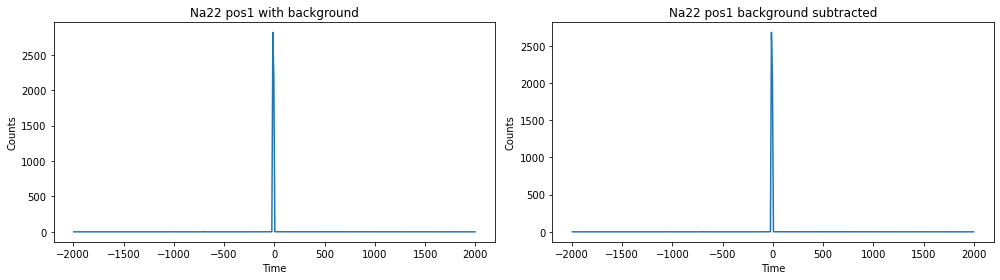

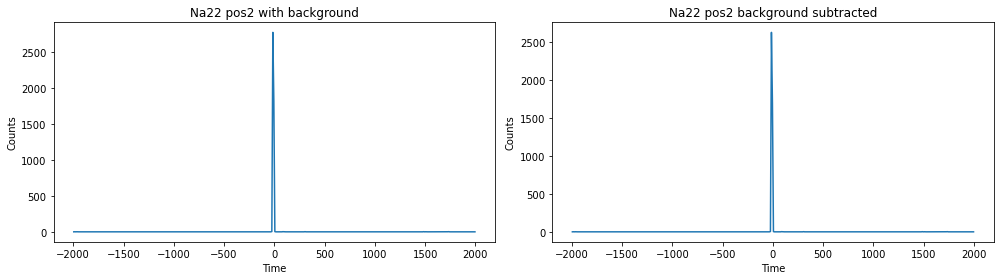

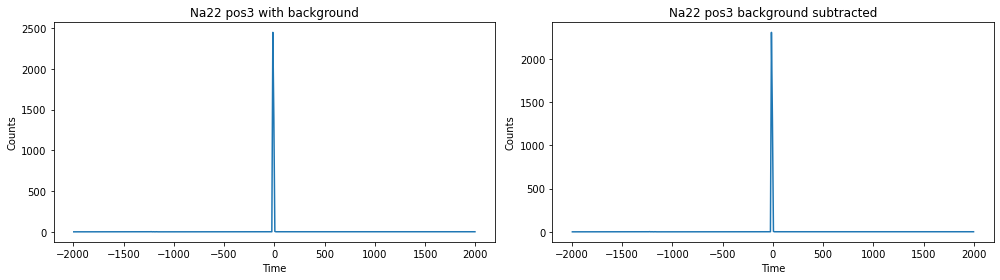

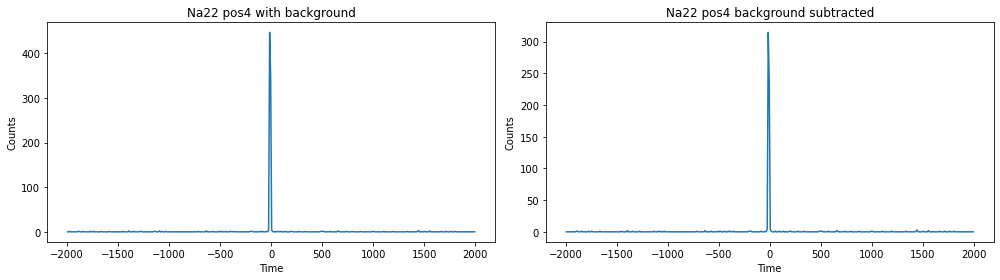

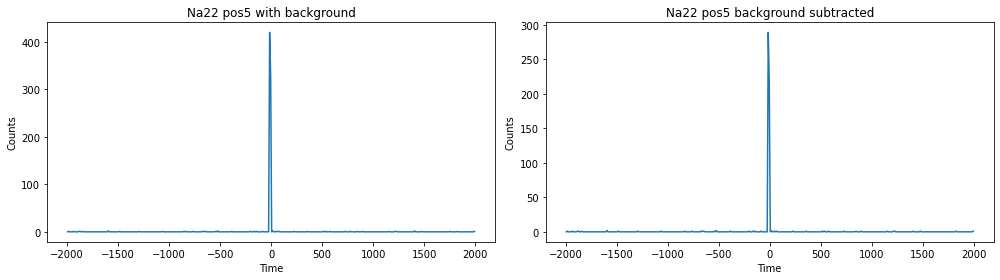

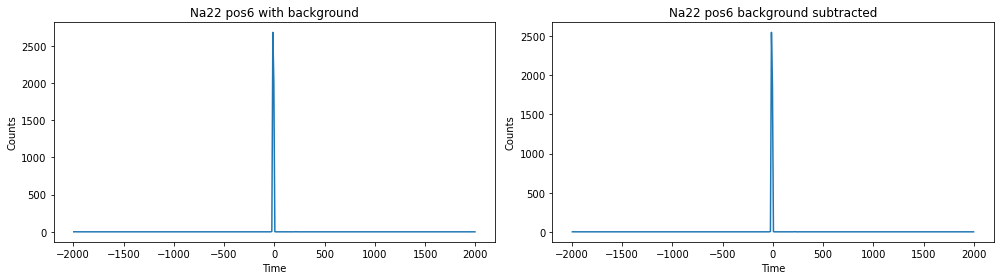

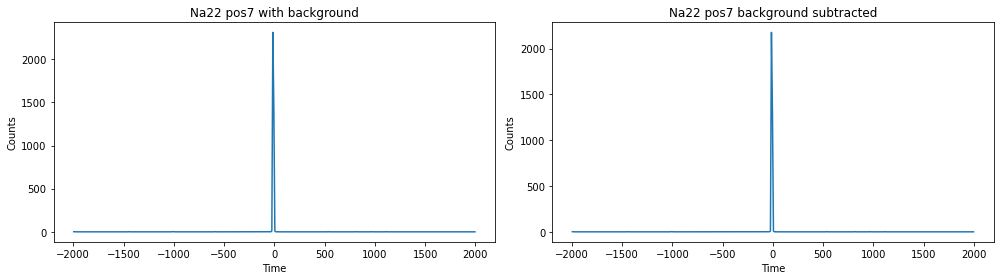

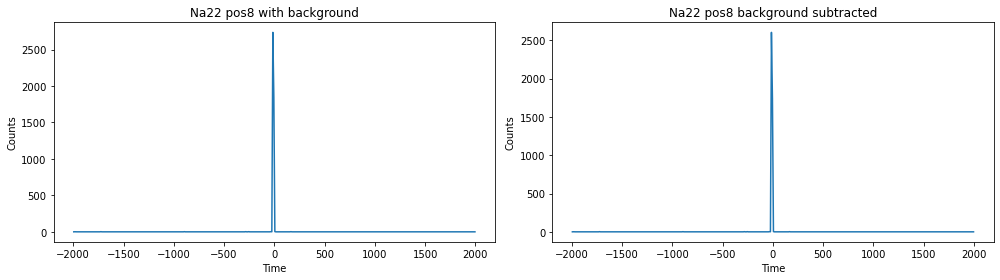

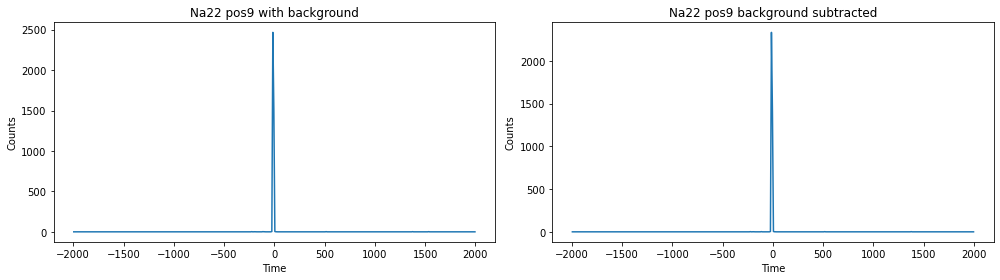

In [10]:
for key in na22d:
    range_na22 = (na22d[key]["ctime"] > -2000) & (na22d[key]["ctime"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22d[key]["ctime"][range_na22], na22d[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22d[key]["ctime"][range_na22], na22d[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

#### 18/03

In [11]:
for key in na22m:
    counts_bg_na22 = bg["m"]["counts"] * (na22m[key]["time"] / bg["m"]["time"])
    na22m[key]["netcounts"] = na22m[key]["counts"] - counts_bg_na22
    na22m[key]["netcounts"][na22m[key]["netcounts"] < 0] = 0

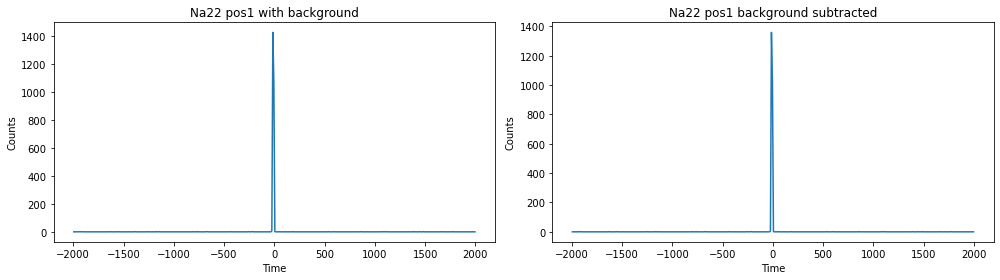

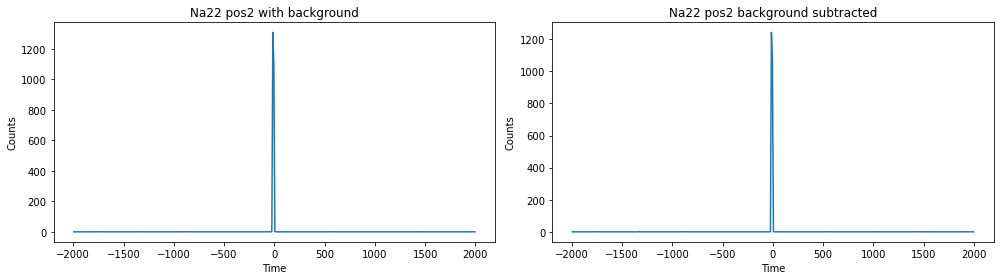

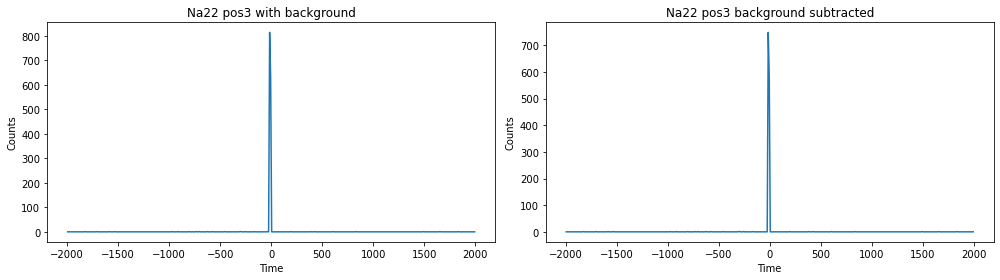

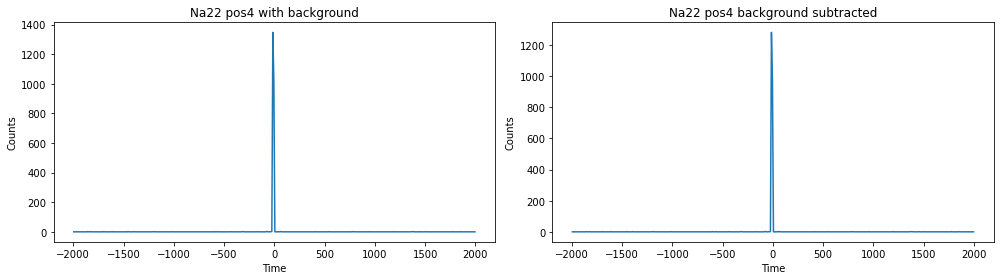

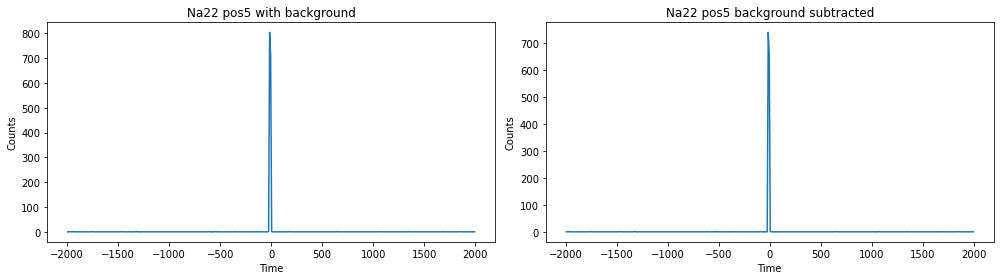

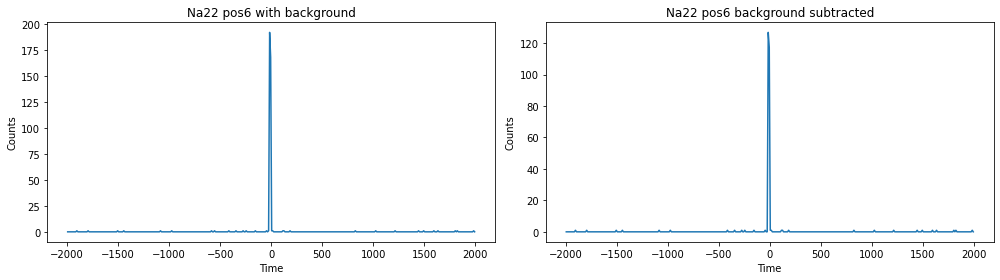

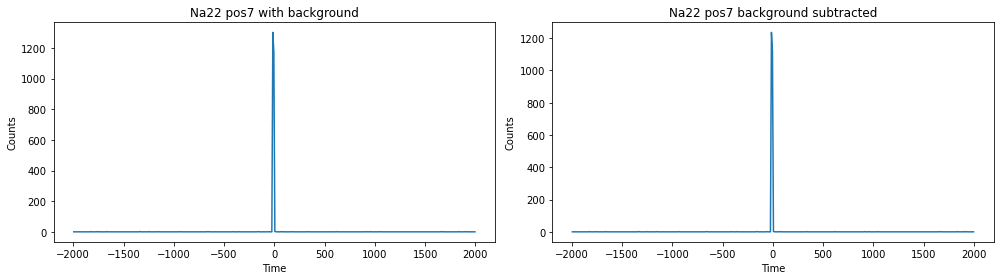

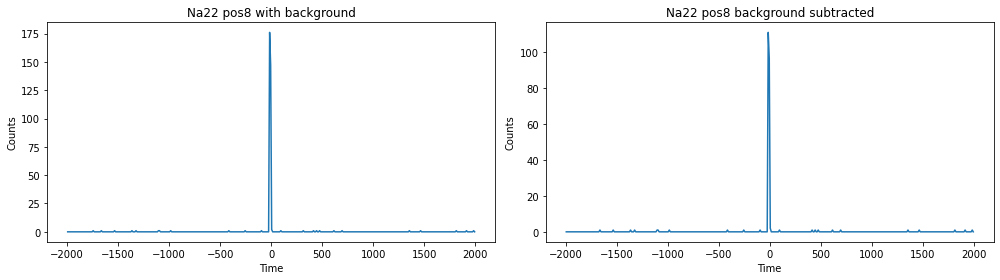

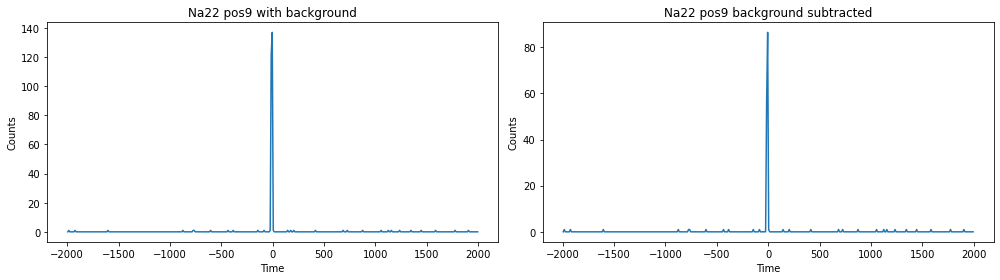

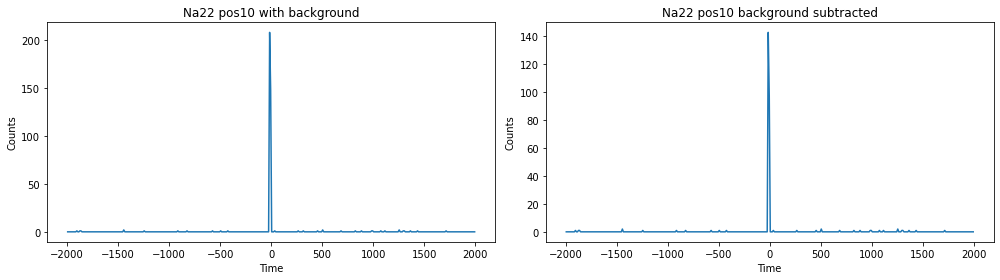

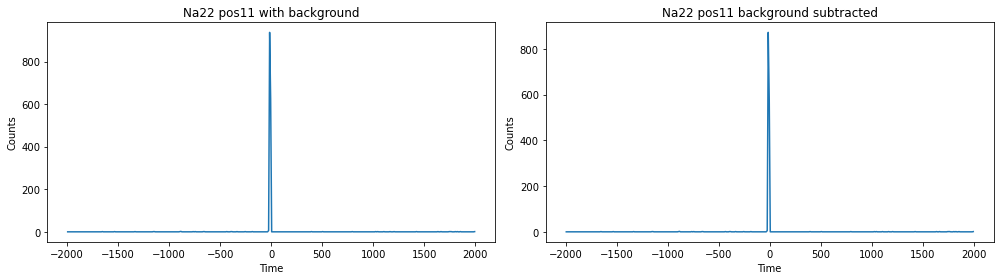

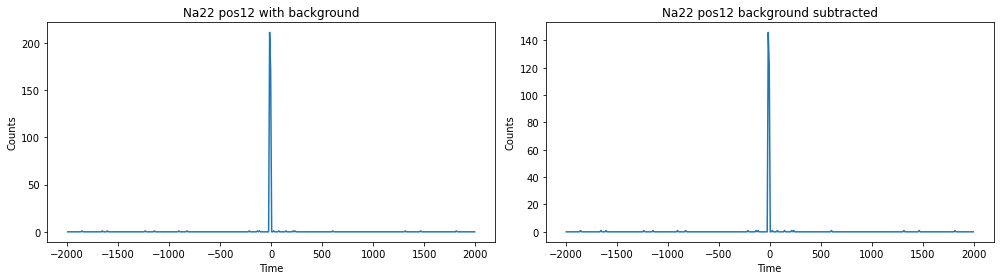

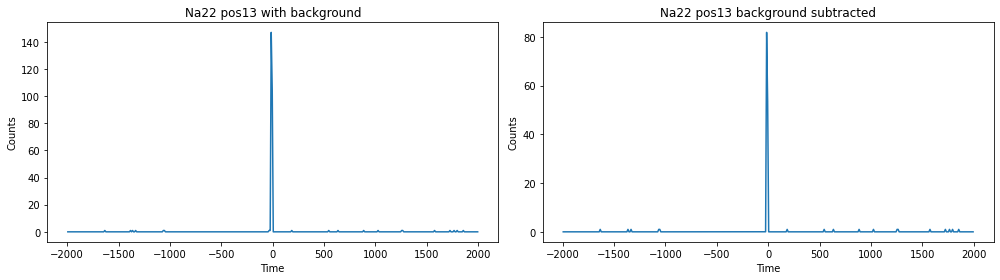

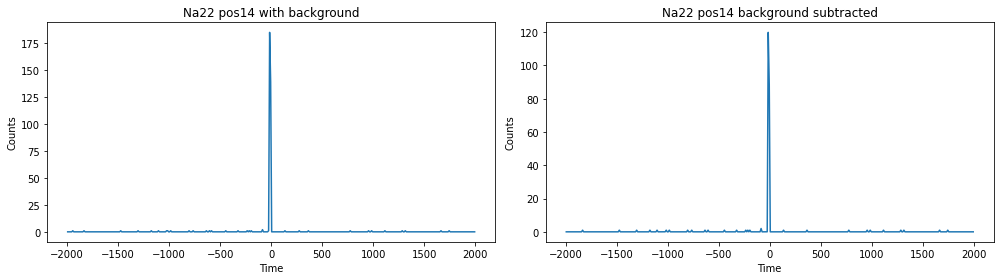

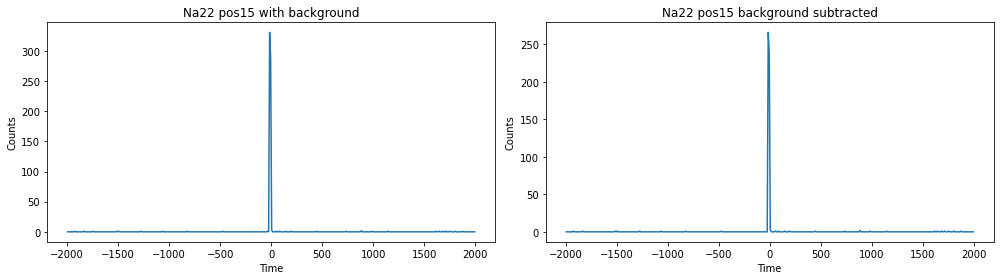

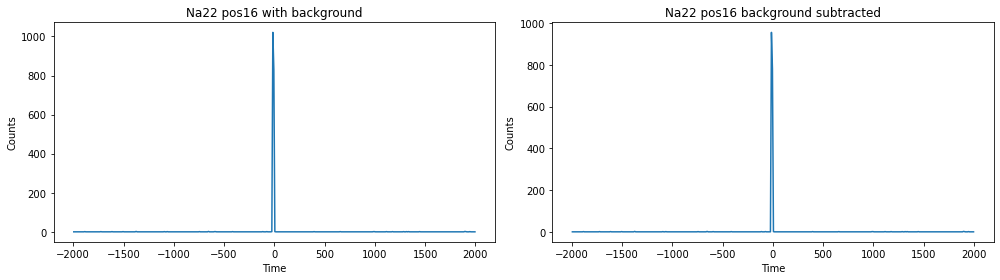

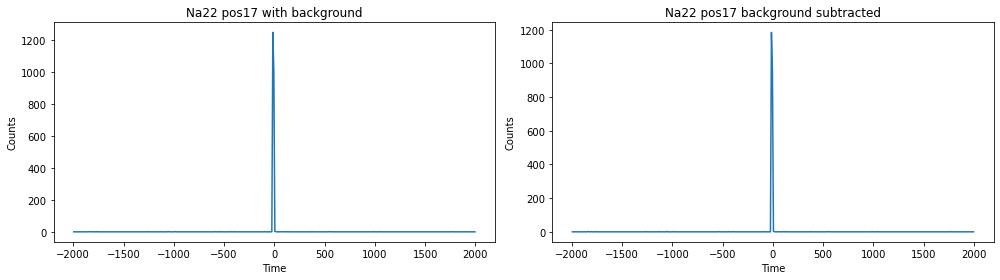

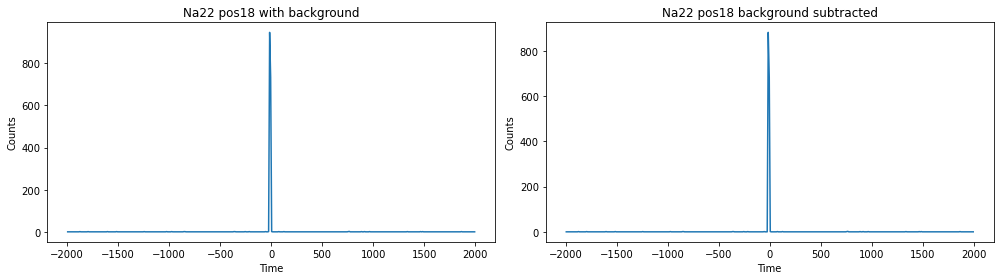

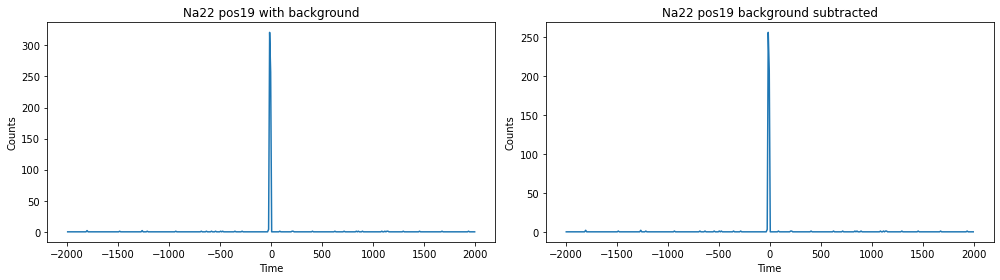

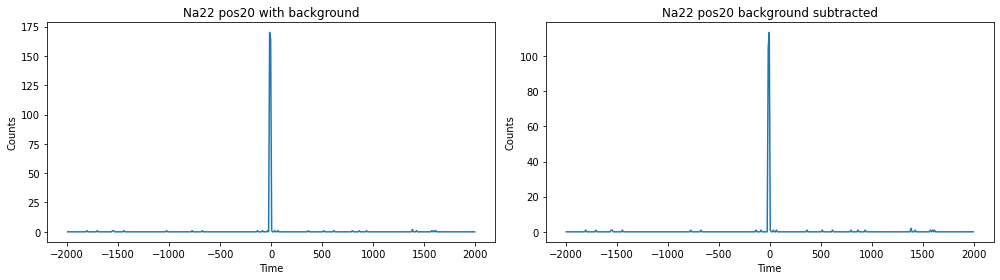

In [12]:
for key in na22m:
    range_na22 = (na22m[key]["ctime"] > -2000) & (na22m[key]["ctime"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4)) 
    
    ax[0].plot(na22m[key]["ctime"][range_na22], na22m[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22m[key]["ctime"][range_na22], na22m[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    display(plt.gcf())  
    plt.close()

---

# Statistical errors

#### 17/12

In [13]:
for key in na22d:
    na22d[key]["sigma_counts"] = np.sqrt(na22d[key]["counts"] + (na22d[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22d[key]["sigma_counts"][na22d[key]["sigma_counts"] == 0] = 1

#### 18/03

In [14]:
for key in na22m:
    na22m[key]["sigma_counts"] = np.sqrt(na22m[key]["counts"] + (na22m[key]["time"] / bg["d"]["time"])**2 * bg["d"]["counts"])
    na22m[key]["sigma_counts"][na22m[key]["sigma_counts"] == 0] = 1

---

# Get counts

#### 17/12

In [15]:
for key in na22d:
    indices = np.argsort(na22d[key]["netcounts"])[-5:][::-1]
    print(indices)
    
    #for i in indices:
        #print(na22d[key]["netcounts"][i])
    #print()

[198 199 197 129 217]
[198 199 197 200 373]
[198 199 200  77 372]
[198 199 197 200 344]
[198 199 147 201  40]
[198 199 197 200 221]
[198 199 197 200 311]
[198 199 200 174 171]
[198 199 200 197 188]


In [16]:
countsd = []
counts_errd = []
for key in na22d:
    counts = na22d[key]["netcounts"][198] + na22d[key]["netcounts"][199]
    countsd.append(counts)
    error = np.sqrt(na22d[key]["sigma_counts"][198]**2 + na22d[key]["sigma_counts"][199]**2)
    counts_errd.append(error)
print(countsd)
print(counts_errd)
print(len(countsd))

[4732.100097025379, 4324.5962006379, 3578.9761452681987, 549.717791081606, 508.02266205888765, 4448.070764415494, 3492.8624376458592, 4340.209247100858, 3729.5551589834504]
[72.54502850912434, 69.76138037401724, 64.46834343137905, 32.54561227255953, 31.734669257677098, 70.31250996920551, 63.361300837202414, 69.53814637148407, 65.13637556803893]
9


#### 18/03

In [17]:
for key in na22m:
    indices = np.argsort(na22m[key]["netcounts"])[-5:][::-1]
    print(indices)
    
    #for i in indices:
        #print(na22m[key]["netcounts"][i])
    #print()

[198 199 197 200 309]
[198 199  67 200 197]
[198 199 260 219 170]
[198 199 192 197 168]
[198 199  67 384  53]
[198 199 158 212 175]
[198 199 200  66 133]
[198 199 200 244  63]
[199 198 139 220 161]
[198 199 325  55 250]
[198 199 197 111 166]
[198 199 381 109 117]
[198 199 325 372  36]
[198 199 191 295  16]
[198 199 200 288  50]
[198 199  62 134 389]
[198 199 200  94  73]
[198 199 276 275 348]
[198 199 197  19  73]
[199 198 338 132  29]


In [18]:
countsm = []
counts_errm = []
for key in na22m:
    counts = na22m[key]["netcounts"][198] + na22m[key]["netcounts"][199]
    countsm.append(counts)
    error = np.sqrt(na22m[key]["sigma_counts"][198]**2 + na22m[key]["sigma_counts"][199]**2)
    counts_errm.append(error)
print(countsm)
print(counts_errm)
print(len(countsm))

[2384.3263209481474, 2295.317440688316, 1328.3170547245795, 2257.3224605373107, 1396.3220738001, 244.31666837410603, 2357.3251630569393, 207.3189853167353, 143.32052994515485, 240.32246015057345, 1445.3170551113167, 266.32593498441156, 135.31358027747862, 208.33095444666918, 503.32554863393807, 1736.3224605373107, 2140.327865576567, 1565.3193712804714, 462.3182133892627, 218.32052955841763]
[50.5547736488941, 49.66682700013844, 38.72717491068721, 49.28274406138406, 39.59531835016704, 20.391038454147765, 50.287038643299994, 19.462584985630674, 17.742342697738838, 20.292581466952807, 40.20937796323033, 20.923324567659353, 17.51563381886309, 19.487962172848487, 25.97664111486667, 43.6782424351059, 48.08101131285101, 41.6748346370784, 25.17524496239823, 19.743118415717497]
20


---

# Table

#### 17/12

##### translational measurements (middle x-axis)
1. (4,1): 4.2cm from LaBr3(Ce), 10.2cm from CeBr3 
2. (4,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3
3. (4,7): 10.2cm from LaBr3(Ce), 4.2cm from CeBr3
4. (1,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
5. (7,4): 7.2cm from LaBr3(Ce), 7.2cm from CeBr3 BUT 3cm away from middle (Pythagoras: 7.8 cm)
6. (4,2): 5.2cm from LaBr3(Ce), 9.2cm from CeBr3 
7. (4,6): 9.2cm from LaBr3(Ce), 5.2cm from CeBr3 
8. (4,3): 6.2cm from LaBr3(Ce), 8.2cm from CeBr3 
9. (4,5): 8.2cm from LaBr3(Ce), 6.2cm from CeBr3 

In [19]:
translationalx0 = np.array([4.2, 7.2, 10.2, 7.8, 7.8, 5.2, 9.2, 6.2, 8.2])
translationalx1 = np.array([10.2, 7.2, 4.2, 7.8, 7.8, 9.2, 5.2, 8.2, 6.2])

In [20]:
time = []
for key in na22d:
    t = na22d[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": na22d.keys(),
    "LaBr3(Ce) [cm]": translationalx0,
    "CeBr3 [cm]": translationalx1,
    "Counts": countsd,
    "Time [s]": time
})
print(table)

  Pos  LaBr3(Ce) [cm]  CeBr3 [cm]       Counts    Time [s]
0   1             4.2        10.2  4732.100097  669.836122
1   2             7.2         7.2  4324.596201  679.190595
2   3            10.2         4.2  3578.976145  707.543323
3   4             7.8         7.8   549.717791  652.168636
4   5             7.8         7.8   508.022662  643.345508
5   6             5.2         9.2  4448.070764  640.547353
6   7             9.2         5.2  3492.862438  662.461406
7   8             6.2         8.2  4340.209247  640.177641
8   9             8.2         6.2  3729.555159  655.272555


#### 18/03

##### turn casing
2. (4,4) 0° (casing line -> LaBr3(Ce))
3. (4,4) 90°
4. (4,4) 180°
5. (4,4) 270°

In [21]:
casing = np.array([0,90,180,270]) #2,3,4,5

In [22]:
keys = list(na22m.keys())
time = []
for key in na22m:
    t = na22m[key]["time"]
    time.append(t)
    
table = pd.DataFrame({
    "Pos": keys[1:5],
    "Angle [°]": casing,
    "Counts": countsm[1:5],
    "Time [s]": time[1:5]
})
print(table)

  Pos  Angle [°]       Counts    Time [s]
0   2          0  2295.317441  299.124460
1   3         90  1328.317055  299.125458
2   4        180  2257.322461  299.111480
3   5        270  1396.322074  299.112480


##### rotational measurements
6. (7,1) 0° (casing line -> CeBr3)
7. 45° (source closest to LaBr3(Ce))
8. 90°
9. 135° (source in middle (wall side))
10. 180°
11. 225° (source closest to CeBr3)
12. 270°
13. 315°

In [23]:
rotational = np.array([0,45,90,135,180,225,270,315]) #6,7,8,9,10,11,12,13

In [24]:
table = pd.DataFrame({
    "Pos": keys[5:13],
    "Angle [°]": rotational,
    "Counts": countsm[5:13],
    "Time [s]": time[5:13]
})
print(table)

  Pos  Angle [°]       Counts    Time [s]
0   6          0   244.316668  299.126457
1   7         45  2357.325163  299.104492
2   8         90   207.318985  299.120466
3   9        135   143.320530  299.116472
4  10        180   240.322460  299.111481
5  11        225  1445.317055  299.125457
6  12        270   266.325935  299.102496
7  13        315   135.313580  299.134442


##### translational measurements (middle y-axis)
14. (7,4)(bottom middle hole)(casing line -> CeBr3)
15. (6,4)
16. (5,4)
17. (4,4)(middle hole)
18. (3,4)
19. (2,4)
20. (1,4)

In [25]:
translationaly = np.array([-3,-2,-1,0,1,2,3]) #14,15,16,17,18,19,20

In [26]:
table = pd.DataFrame({
    "Pos": keys[13:20],
    "Distance [cm]": translationaly,
    "Counts": countsm[13:20],
    "Time [s]": time[13:20]
})
print(table)

  Pos  Distance [cm]       Counts    Time [s]
0  14             -3   208.330954  299.089517
1  15             -2   503.325549  299.103495
2  16             -1  1736.322461  299.111480
3  17              0  2140.327866  299.097504
4  18              1  1565.319371  299.119468
5  19              2   462.318213  299.122462
6  20              3   218.320530  299.116473


---

# Count rate

#### 17/12

In [27]:
t = []
for key in na22d:
    time = na22d[key]["time"]
    t.append(time)

In [28]:
time = np.array(t)
rated = countsd/time
rate_errd = counts_errd/time
print(rated)
print(rate_errd)
print(len(rated))

[7.06456392 6.36727928 5.05831379 0.84290743 0.78965759 6.94417164
 5.27255234 6.77969515 5.69160898]
[0.10830265 0.10271252 0.09111575 0.04990368 0.04932757 0.10976942
 0.09564527 0.1086232  0.09940348]
9


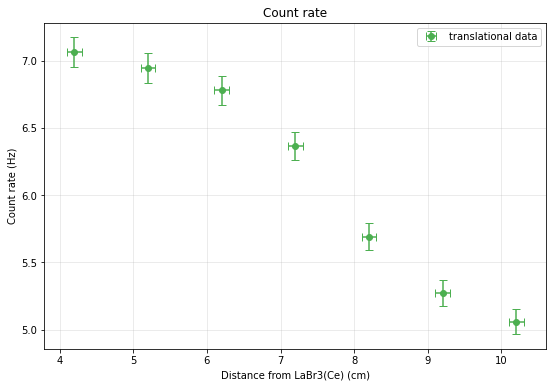

In [41]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(translationalx0[[0,1,2,5,6,7,8]], rated[[0,1,2,5,6,7,8]], xerr=0.1, yerr=rate_errd[[0,1,2,5,6,7,8]], fmt='o', color='#4CAF50', label='translational data', capsize=4)
plt.xlabel("Distance from LaBr3(Ce) (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 18/03

In [30]:
t = []
for key in na22m:
    time = na22m[key]["time"]
    t.append(time)

In [32]:
time = np.array(t)
ratem = countsm/time
rate_errm = counts_errm/time
print(ratem)
print(rate_errm)
print(len(ratem))

[7.97162949 7.67345285 4.44066869 7.54675969 4.66821737 0.81676717
 7.88127636 0.69309529 0.47914623 0.80345448 4.83180893 0.89041696
 0.45235039 0.69655051 1.68278057 5.8049342  7.15595362 5.23309092
 1.54558173 0.72988467]
[0.16902213 0.16604067 0.129468   0.1647638  0.13237602 0.06816862
 0.16812532 0.06506604 0.05931583 0.06784287 0.13442312 0.06995369
 0.05855439 0.06515762 0.08684834 0.14602663 0.16075364 0.13932505
 0.08416367 0.06600478]
20


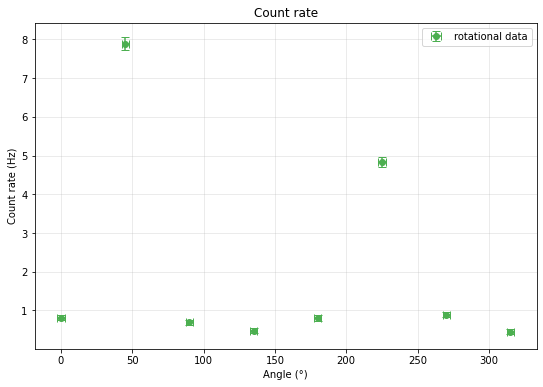

In [38]:
fig = plt.figure(figsize=(9,6))
plt.errorbar(rotational, ratem[5:13], xerr=2.5, yerr=rate_errm[5:13], fmt='o', color='#4CAF50', label='rotational data', capsize=4)
plt.xlabel("Angle (°)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

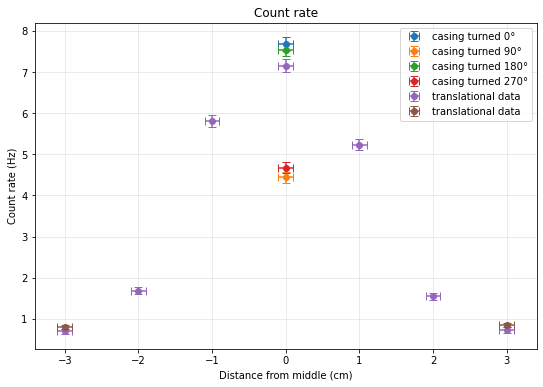

In [37]:
fig = plt.figure(figsize=(9,6))
plt.errorbar([0], ratem[1], xerr=0.1, yerr=rate_errm[1], fmt='o', label='casing turned 0°', capsize=4)
plt.errorbar([0], ratem[2], xerr=0.1, yerr=rate_errm[2], fmt='o', label='casing turned 90°', capsize=4)
plt.errorbar([0], ratem[3], xerr=0.1, yerr=rate_errm[3], fmt='o', label='casing turned 180°', capsize=4)
plt.errorbar([0], ratem[4], xerr=0.1, yerr=rate_errm[4], fmt='o', label='casing turned 270°', capsize=4)
plt.errorbar(translationaly, ratem[13:20], xerr=0.1, yerr=rate_errm[13:20], fmt='o', label='translational data', capsize=4)
plt.errorbar([3,-3], rated[3:5], xerr=0.1, yerr=rate_errd[3:5], fmt='o', label='translational data', capsize=4)
plt.xlabel("Distance from middle (cm)")
plt.ylabel("Count rate (Hz)")
plt.title("Count rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()